# Inspect I2SB training data & choose `tau`

Loads batches through the **exact training path** (`config -> build_loader`) so what you see is
what the model sees: same `image_key`, `scales`, crop, and endpoints (`x1 = T1` prior, `x0 = T1CE`
target). Then it visualizes the bridge interpolant `x_t = (1-t) x0 + t x1 + std_sb(t)*noise` for
several candidate `tau`, so you can pick the `tau` where the injected noise is visible but doesn't
swamp anatomy.

**Prereqs:** run on the machine with the BraTS data + a modern torch. The default config uses
`image_key: "img_raw"`, so the h5 must have been regenerated with `save_raw_image: true`
(otherwise set `IMAGE_KEY_OVERRIDE = "img"` in the loader cell).

In [56]:
import os, sys, yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline

# # notebook lives in notebooks/; repo root is the parent
# REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
# if REPO_ROOT not in sys.path:
#     sys.path.insert(0, REPO_ROOT)
# os.chdir(REPO_ROOT)
# print("repo root:", REPO_ROOT)
os.chdir('/scratch/ee2178/ImMAP')

CONFIG = "config/BraTS/i2sb_paper.json"   # the exact training config
SPLIT  = "train"                    # "train" or "val"

## 1. Build the loader exactly as `train.py` does

In [57]:
import datasets                        # side-effect import: registers the loaders
from datasets.registry import build_loader

IMAGE_KEY_OVERRIDE = None            # None = use config; or "img" (normalized) / "img_raw" (raw)

with open(CONFIG) as f:
    cfg = yaml.safe_load(f)

data_cfg = dict(cfg["data"][SPLIT])
data_cfg["num_workers"] = 0          # only affects speed, not the data seen
if IMAGE_KEY_OVERRIDE is not None:
    data_cfg["image_key"] = IMAGE_KEY_OVERRIDE

shuffle = (SPLIT == "train")         # train.py: shuffle=True for train, False for val
loader  = build_loader(data_cfg, shuffle=shuffle, drop_last=(SPLIT == "train"))

print("split           :", SPLIT)
print("dataset size    :", len(loader.dataset))
print("batch size      :", loader.batch_size)
print("image_key       :", data_cfg.get("image_key", "img"))
print("scales          :", data_cfg.get("scales"))
print("x0_idx (target) :", data_cfg.get("x0_idx"), " x1_idx (prior):", data_cfg.get("x1_idx"))
print("cond_idx        :", data_cfg.get("cond_idx"))

split           : train
dataset size    : 40912
batch size      : 8
image_key       : img
scales          : [1, 1, 1, 1]
x0_idx (target) : 2  x1_idx (prior): 1
cond_idx        : []


In [58]:
x0, x1, cond, mask = next(iter(loader))   # x0 = T1CE target, x1 = T1 prior
print("x0 (T1CE):", tuple(x0.shape))
print("x1 (T1)  :", tuple(x1.shape))
print("cond     :", tuple(cond.shape), "(0 channels => conditioning off)")
print("mask     :", tuple(mask.shape))
print("dtype    :", x0.dtype, " | x0 range:", float(x0.min()), "->", float(x0.max()))

x0 (T1CE): (8, 1, 128, 128)
x1 (T1)  : (8, 1, 128, 128)
cond     : (8, 0, 128, 128) (0 channels => conditioning off)
mask     : (8, 1, 128, 128)
dtype    : torch.float32  | x0 range: -2.9312546253204346 -> 8.211791038513184


## 2. Sanity check — a few `T1 | T1CE | mask` triples

Confirms the raw intensities, orientation, and alignment look right. All panels share one display
window (brain-region percentiles) so intensities are comparable.

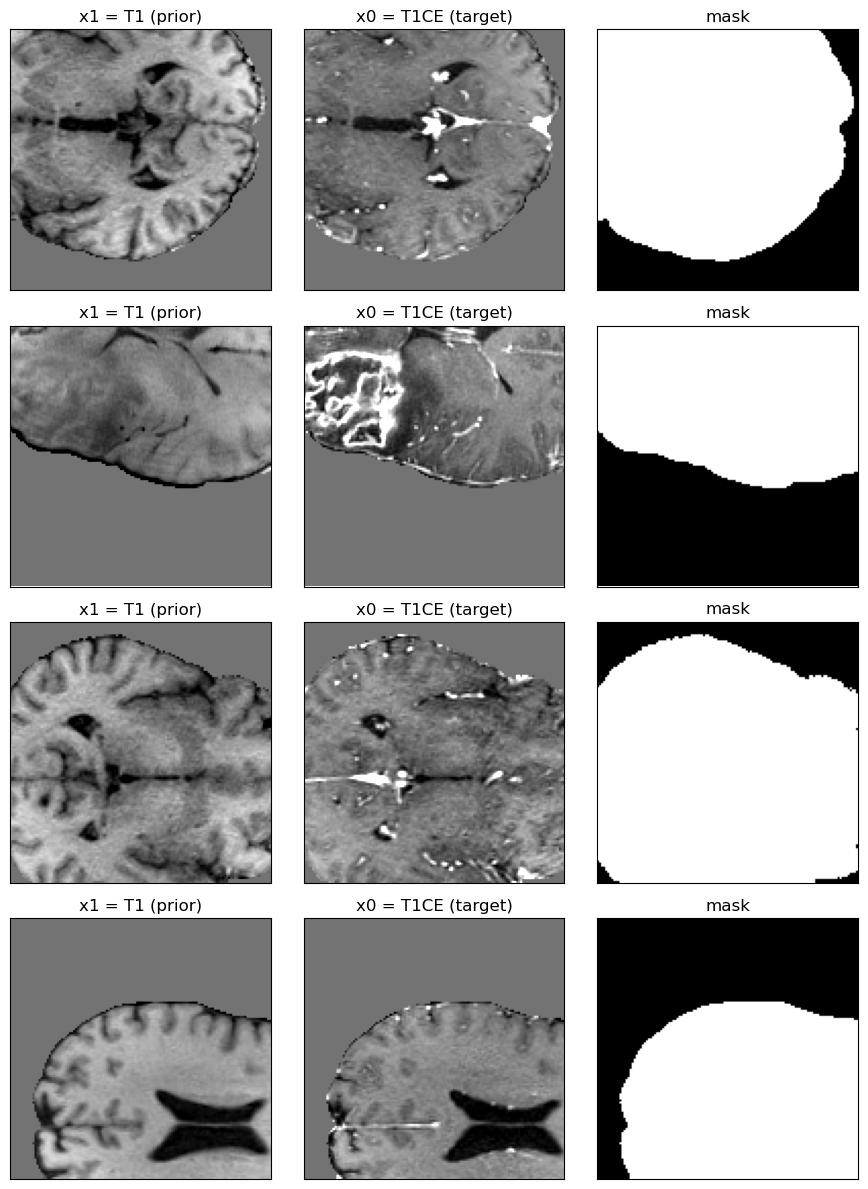

display window: [-2.2, 2.7]


In [59]:
def qtile(v, ps):
    """Quantiles with a subsample guard for very large tensors."""
    v = v.flatten().float()
    if v.numel() > 1_000_000:
        v = v[torch.randint(0, v.numel(), (1_000_000,))]
    return torch.quantile(v, torch.as_tensor(ps, dtype=torch.float32))

def disp_window(*imgs, m=None, lo=1, hi=99):
    """Shared [lo, hi]-percentile display window from the brain region."""
    vals = []
    for im in imgs:
        vals.append(im[m.bool().expand_as(im)] if m is not None else im.flatten())
    v = torch.cat([x.flatten() for x in vals])
    p = qtile(v, [lo / 100, hi / 100])
    return float(p[0]), float(p[1])

nshow = min(4, x0.shape[0])
vmin, vmax = disp_window(x1[:nshow], x0[:nshow], m=mask[:nshow])
fig, ax = plt.subplots(nshow, 3, figsize=(9, 3 * nshow))
ax = np.atleast_2d(ax)
for i in range(nshow):
    ax[i, 0].imshow(x1[i, 0].numpy(), cmap="gray", vmin=vmin, vmax=vmax); ax[i, 0].set_title("x1 = T1 (prior)")
    ax[i, 1].imshow(x0[i, 0].numpy(), cmap="gray", vmin=vmin, vmax=vmax); ax[i, 1].set_title("x0 = T1CE (target)")
    ax[i, 2].imshow(mask[i, 0].numpy(), cmap="gray"); ax[i, 2].set_title("mask")
    for a in ax[i]: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print(f"display window: [{vmin:.1f}, {vmax:.1f}]")

<Axes: title={'center': 'T1CE  [0, 2]'}>

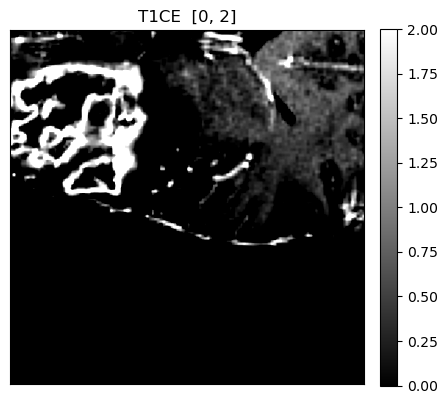

In [60]:
def show_clipped(img, vmin=None, vmax=None, pmin=None, pmax=None,
                 mask=None, cmap="gray", ax=None, title=None, colorbar=True):
    """Display a 2D image, clipping the display range at chosen thresholds.

    Thresholds (any combination; percentile wins if both given for a side):
        vmax / vmin : absolute intensity clip
        pmax / pmin : percentile clip in [0, 100]
    mask : optional brain mask -> percentiles use in-brain pixels only.
    Accepts numpy or torch, shape (H,W), (1,H,W), or (B,1,H,W) (uses the first slice).
    """
    import numpy as np, matplotlib.pyplot as plt
    x = img.detach().cpu().numpy() if hasattr(img, "detach") else np.asarray(img)
    x = np.squeeze(x)
    while x.ndim > 2:                      # (B,1,H,W)/(1,H,W) -> first slice
        x = x[0]
    x = x.astype(np.float32)

    m = None
    if mask is not None:
        m = mask.detach().cpu().numpy() if hasattr(mask, "detach") else np.asarray(mask)
        m = np.squeeze(m)
        while m.ndim > 2:
            m = m[0]
        m = m.astype(bool)
    pool = x[m] if (m is not None and m.shape == x.shape) else x.ravel()

    hi = np.percentile(pool, pmax) if pmax is not None else (vmax if vmax is not None else pool.max())
    lo = np.percentile(pool, pmin) if pmin is not None else (vmin if vmin is not None else pool.min())

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(x, cmap=cmap, vmin=lo, vmax=hi)   # imshow clamps display to [lo, hi]
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title or f"clip [{lo:.4g}, {hi:.4g}]")
    if colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax


# --- examples ---
# clip the bright tail at the 99th percentile (within the brain)
# show_clipped(x0[0], pmax=99, mask=mask[0], title="T1CE  clip@p99")

# absolute intensity window instead:
# show_clipped(x0[1], vmin=0, vmax=2, title="T1CE  [0, 2]")

# sweep thresholds to find one you like:
# import matplotlib.pyplot as plt
# ps = [95, 98, 99, 99.5, 100]
# fig, ax = plt.subplots(1, len(ps), figsize=(3*len(ps), 3))
# for a, p in zip(ax, ps):
#     show_clipped(x0[0], pmax=p, mask=mask[0], ax=a, colorbar=False, title=f"p{p}")
# plt.tight_layout(); plt.show()

## 3. Intensity statistics — the scale `tau` must match

`tau` is an **absolute** std, so what matters is its size relative to the signal. Accumulate
in-brain intensities over several batches for `x0` (T1CE), `x1` (T1), and the enhancement
`x0 - x1` (the gap the bridge must cross).

In [63]:
idx = 0
x0[idx][mask[idx].bool()].std()

tensor(0.9309)

In [64]:
N_BATCHES = 8
acc = {"x0 (T1CE)": [], "x1 (T1)": [], "x0 - x1 (enhancement)": []}
it = iter(loader)
for _ in range(N_BATCHES):
    try:
        a0, a1, _, am = next(it)
    except StopIteration:
        break
    mb = am.bool()
    acc["x0 (T1CE)"].append(a0[mb])
    acc["x1 (T1)"].append(a1[mb])
    acc["x0 - x1 (enhancement)"].append((a0 - a1)[mb])
acc = {k: torch.cat(v).float() for k, v in acc.items()}

print(f"{'quantity':24s} {'mean':>9} {'std':>9} {'p1':>9} {'p50':>9} {'p99':>9} {'max':>11}")
for k, v in acc.items():
    p = qtile(v, [0.01, 0.5, 0.99])
    print(f"{k:24s} {v.mean():9.2f} {v.std():9.2f} {p[0]:9.2f} {p[1]:9.2f} {p[2]:9.2f} {v.max():11.2f}")

quantity                      mean       std        p1       p50       p99         max
x0 (T1CE)                     0.06      0.97     -2.15      0.06      3.65        8.91
x1 (T1)                       0.10      0.96     -2.40      0.22      1.85        5.76
x0 - x1 (enhancement)        -0.03      0.96     -1.36     -0.23      4.10       11.69


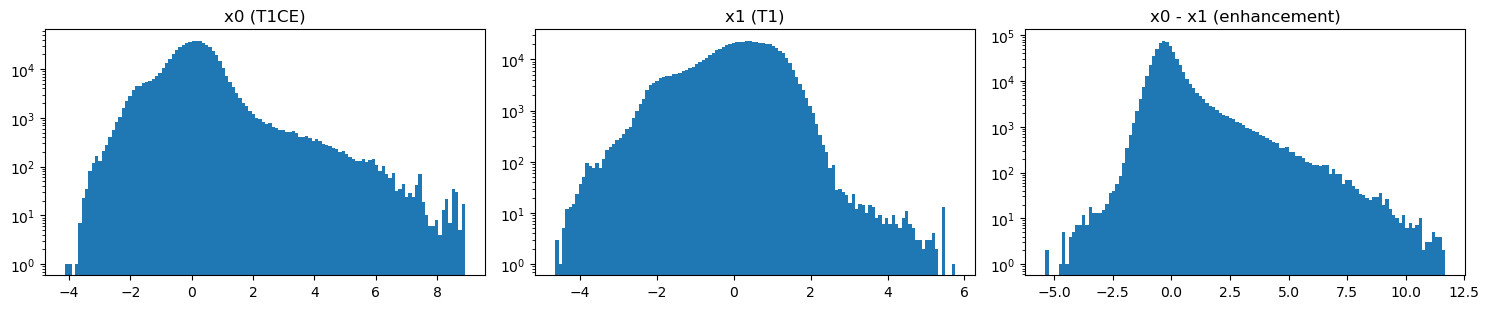

In [65]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
for a, (k, v) in zip(ax, acc.items()):
    a.hist(v.numpy(), bins=120); a.set_title(k); a.set_yscale("log")
plt.tight_layout(); plt.show()

## 4. Bridge `tau` sweep (the main visual)

Each row is a candidate `tau` (peak bridge-noise std); each column is a bridge time `t`
(`t = 0` -> pure T1CE, `t = 1` -> pure T1). Cells show `x_t` sampled through the **actual**
`q_sample`. The yellow number is the injected noise std `std_sb(t)` at that cell. Pick the
`tau` where noise is clearly present near the middle but anatomy is still legible.

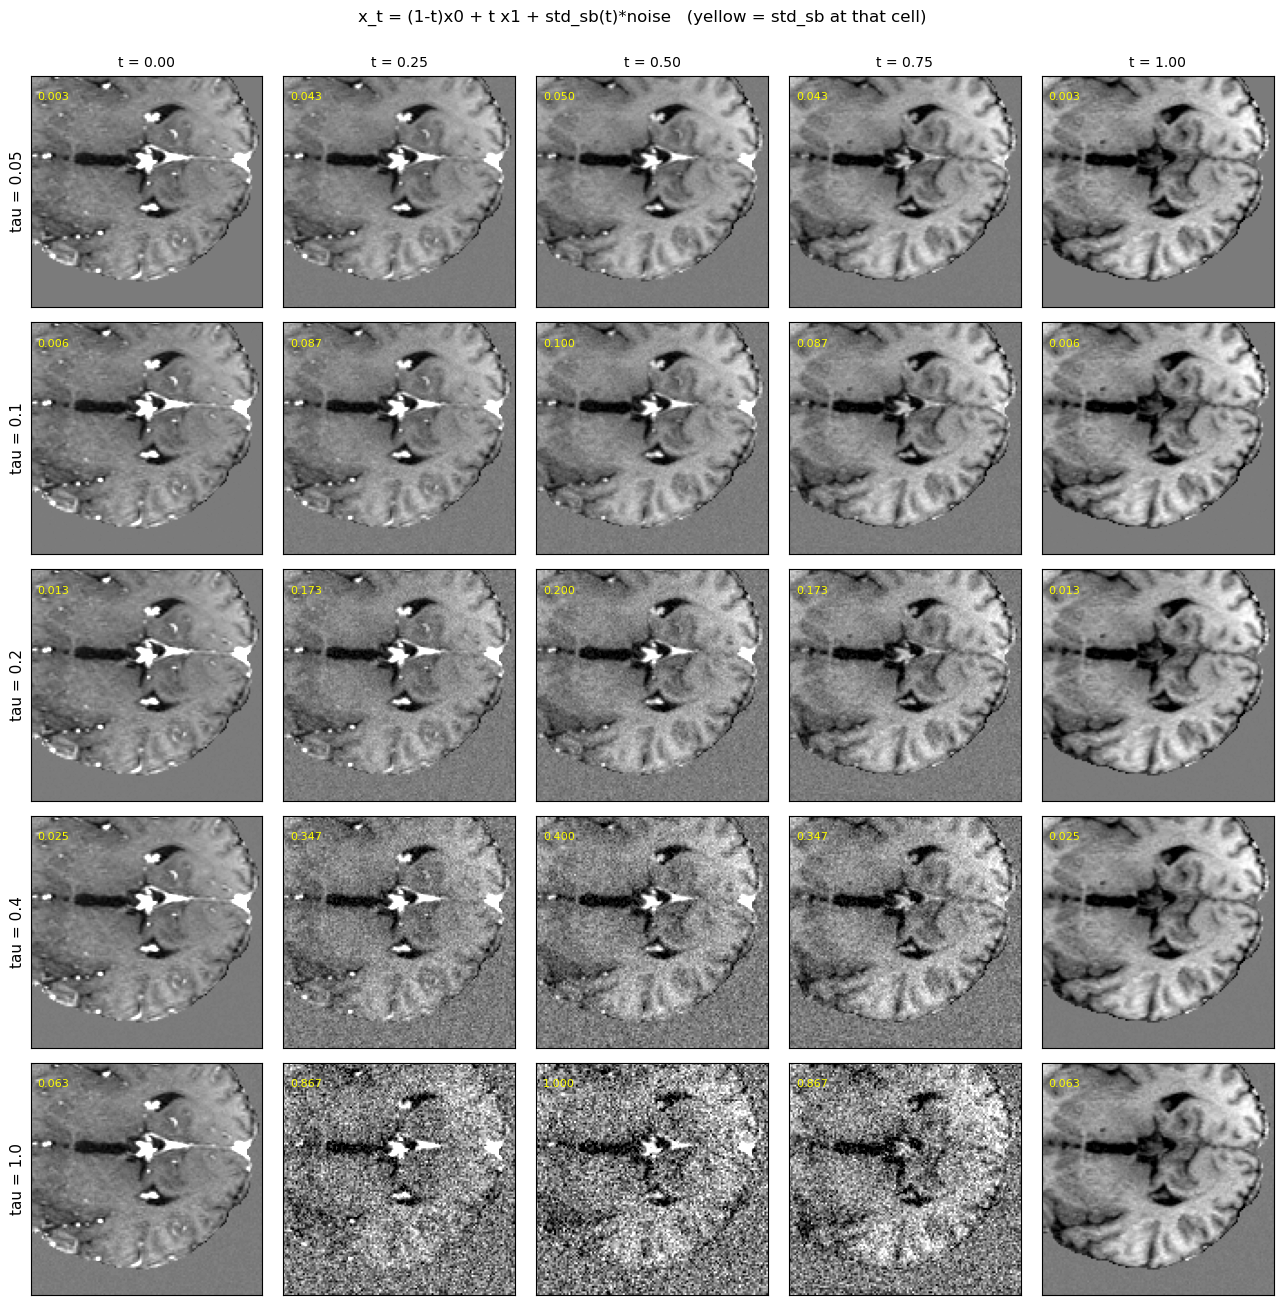

In [66]:
from physics.bbridge import brownian_bridge_schedule
from diffusion.i2sb import q_sample

# --- edit these ---
CANDIDATE_TAUS = [0.05, 0.1, 0.2, 0.4, 1.0]          # peak bridge-noise std to try
T_FRACS        = [0.0, 0.25, 0.5, 0.75, 1.0]    # bridge times (0 -> x0/T1CE, 1 -> x1/T1)
EXAMPLE        = 0                              # which slice in the batch
SEED           = 0

n     = int(cfg["i2sb"]["n_points"])
shape = cfg["i2sb"].get("bridge_shape", "constant")
x0b, x1b, mb = x0[EXAMPLE:EXAMPLE+1], x1[EXAMPLE:EXAMPLE+1], mask[EXAMPLE:EXAMPLE+1]
vmin, vmax = disp_window(x1b, x0b, m=mb)

fig, axes = plt.subplots(len(CANDIDATE_TAUS), len(T_FRACS),
                         figsize=(2.6 * len(T_FRACS), 2.6 * len(CANDIDATE_TAUS)))
axes = np.atleast_2d(axes)
for i, tau in enumerate(CANDIDATE_TAUS):
    sched = brownian_bridge_schedule(tau=tau, n=n, shape=shape)
    torch.manual_seed(SEED)
    for j, tf in enumerate(T_FRACS):
        k  = int(round(tf * (n - 1)))
        xt = q_sample(sched, torch.full((1,), k, dtype=torch.long), x0b, x1b, ot_ode=False)
        a  = axes[i, j]
        a.imshow(xt[0, 0].numpy(), cmap="gray", vmin=vmin, vmax=vmax)
        a.set_xticks([]); a.set_yticks([])
        a.text(0.03, 0.93, f"{float(sched.std_sb[k]):.3f}", color="yellow",
               fontsize=8, transform=a.transAxes, va="top")
        if i == 0: a.set_title(f"t = {tf:.2f}", fontsize=10)
        if j == 0: a.set_ylabel(f"tau = {tau}", fontsize=11)
fig.suptitle("x_t = (1-t)x0 + t x1 + std_sb(t)*noise   (yellow = std_sb at that cell)", y=1.0)
plt.tight_layout(); plt.show()

## 5. Quantitative guidance

`tau` is scale-dependent, so the useful number is the **ratio** `tau / std(x0)`. The I2SB paper
uses `tau = 0.188` on data normalized to `[-1, 1]` (std ~ 0.3-0.5), i.e. roughly
`tau ~ 0.4-0.6 x signal std`. Aim for a similar fraction here.

In [27]:
sig_std = float(acc["x0 (T1CE)"].std())
enh_std = float(acc["x0 - x1 (enhancement)"].std())
print(f"signal std        std(x0)      = {sig_std:.3f}")
print(f"enhancement std   std(x0 - x1) = {enh_std:.3f}\n")
print(f"{'tau':>8} {'peak std_sb':>12} {'max std_fwd':>12} {'tau/std(x0)':>13} {'tau/std(x0-x1)':>16}")
for tau in CANDIDATE_TAUS:
    print(f"{tau:8.3f} {tau:12.3f} {2*tau:12.3f} {tau/sig_std:13.3f} {tau/enh_std:16.3f}")
print("\nTwo ways to hit a target ratio: change `tau`, or change the per-channel `scales` in the")
print("config (scales bring raw intensities to O(1) so a small absolute tau is a sensible fraction).")
print("With raw intensities, a single global scale won't tame per-subject outliers -- consider a")
print("robust scale (e.g. divide each contrast by a dataset-wide high percentile).")

signal std        std(x0)      = 0.662
enhancement std   std(x0 - x1) = 0.384

     tau  peak std_sb  max std_fwd   tau/std(x0)   tau/std(x0-x1)
   0.050        0.050        0.100         0.075            0.130
   0.100        0.100        0.200         0.151            0.261
   0.200        0.200        0.400         0.302            0.521
   0.400        0.400        0.800         0.604            1.042
   1.000        1.000        2.000         1.510            2.606

Two ways to hit a target ratio: change `tau`, or change the per-channel `scales` in the
config (scales bring raw intensities to O(1) so a small absolute tau is a sensible fraction).
With raw intensities, a single global scale won't tame per-subject outliers -- consider a
robust scale (e.g. divide each contrast by a dataset-wide high percentile).


## 6. Noise-schedule curves for a chosen `tau`

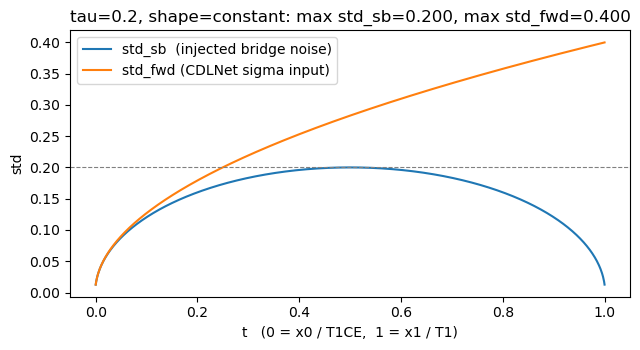

Once decided, set  i2sb.tau = 0.2  in config/BraTS/i2sb_paper.json (and mirror in i2sb_paper.json if
you want the baseline noise-matched).


In [28]:
CHOSEN_TAU = 0.2
sched = brownian_bridge_schedule(tau=CHOSEN_TAU, n=n, shape=shape)
t = np.linspace(0, 1, n)
plt.figure(figsize=(6.5, 3.6))
plt.plot(t, sched.std_sb.numpy(),  label="std_sb  (injected bridge noise)")
plt.plot(t, sched.std_fwd.numpy(), label="std_fwd (CDLNet sigma input)")
plt.axhline(CHOSEN_TAU, ls="--", c="gray", lw=0.8)
plt.xlabel("t   (0 = x0 / T1CE,  1 = x1 / T1)"); plt.ylabel("std"); plt.legend()
plt.title(f"tau={CHOSEN_TAU}, shape={shape}: max std_sb={float(sched.std_sb.max()):.3f}, "
          f"max std_fwd={float(sched.std_fwd.max()):.3f}")
plt.tight_layout(); plt.show()

print(f"Once decided, set  i2sb.tau = {CHOSEN_TAU}  in {CONFIG} (and mirror in i2sb_paper.json if")
print("you want the baseline noise-matched).")